In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

#Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f'Train examples: {len(train_dataset)}')
print(f'Test  examples: {len(test_dataset)}')

# 2NN model
class TwoNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 200)
        self.fc3 = nn.Linear(200, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print('Setup done')


Train examples: 60000
Test  examples: 10000
Setup done


In [3]:
torch.manual_seed(0)
model = TwoNN()

# Small subset for fast training
subset_indices = list(range(5000))
from torch.utils.data import DataLoader, Subset
train_loader = DataLoader(Subset(train_dataset, subset_indices), batch_size=50, shuffle=True)

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

print("Training model for 5 epochs on 5000 examples")
for epoch in range(5):
    total_loss = 0
    correct = 0
    total = 0
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    acc = 100.0 * correct / total
    print(f"Epoch {epoch+1}/5  |  Loss: {total_loss:.2f}  |  Acc: {acc:.1f}%")

# Check test accuracy
model.eval()
correct = 0
total = 0
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
print(f"\nTest accuracy: {100.0 * correct / total:.1f}%")


Training model for 5 epochs on 5000 examples
Epoch 1/5  |  Loss: 83.41  |  Acc: 75.5%
Epoch 2/5  |  Loss: 30.20  |  Acc: 91.2%
Epoch 3/5  |  Loss: 21.77  |  Acc: 93.4%
Epoch 4/5  |  Loss: 15.54  |  Acc: 95.6%
Epoch 5/5  |  Loss: 11.98  |  Acc: 96.6%

Test accuracy: 93.0%


Victim label: 4
Victim image shape: torch.Size([1, 1, 28, 28])


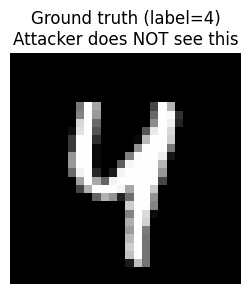


Real gradient shape: torch.Size([199210])
Number of model parameters: 199210


In [4]:
# Pick one private image from the test set
# This is the "secret" the attacker is trying to recover
victim_idx = 42
victim_image, victim_label = test_dataset[victim_idx]

# Add batch dimension
victim_image = victim_image.unsqueeze(0)
victim_label = torch.tensor([victim_label])

print(f"Victim label: {victim_label.item()}")
print(f"Victim image shape: {victim_image.shape}")

# Show the victim image we can see it, but the attacker cannot
plt.figure(figsize=(3, 3))
plt.imshow(victim_image[0, 0].numpy(), cmap='gray')
plt.title(f"Ground truth (label={victim_label.item()})\nAttacker does NOT see this")
plt.axis('off')
plt.show()

# Compute the REAL gradient what the client sends to the server
model.eval()

# Forward pass
output = model(victim_image)
loss = loss_fn(output, victim_label)

# Backward pass — this populates .grad on every weight
model.zero_grad()
loss.backward()

# Collect all gradients into one flat tensor — this is the "leaked" gradient
real_gradients = []
for param in model.parameters():
    real_gradients.append(param.grad.view(-1))
real_gradient = torch.cat(real_gradients)

print(f"\nReal gradient shape: {real_gradient.shape}")
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())}")


In [9]:
# DLG attack


def dlg_attack(model, real_gradient, num_iterations=300, lr=0.1):
    """
    Deep Leakage from Gradients attack.
    Recovers the private training image from the shared gradient.
    """
    # Make sure model params require grad (needed for autograd.grad)
    for param in model.parameters():
        param.requires_grad_(True)


    real_gradient = real_gradient.detach()

    # Initialize dummy data (random noise)
    torch.manual_seed(42)
    dummy_image = torch.randn(1, 1, 28, 28, requires_grad=True)
    dummy_label = torch.randn(1, 10, requires_grad=True)

    optimizer = torch.optim.Adam([dummy_image, dummy_label], lr=lr)
    history = []

    print(f"Attacking... recovering image from gradient of {real_gradient.shape[0]} values")
    print(f"{'Iter':>5} | {'Distance':>12}")
    print("-" * 25)

    for i in range(num_iterations):
        optimizer.zero_grad()

        # Forward pass with dummy data
        dummy_output = model(dummy_image)
        dummy_loss = torch.nn.functional.cross_entropy(dummy_output, dummy_label)

        # FIRST backward: compute dummy gradients (keep graph alive!)
        dummy_grads = torch.autograd.grad(
            dummy_loss,
            list(model.parameters()),
            create_graph=True       # second-order magic
        )

        # Flatten and compute distance to real gradient
        dummy_grad_flat = torch.cat([g.view(-1) for g in dummy_grads])
        grad_distance = ((dummy_grad_flat - real_gradient) ** 2).sum()

        # SECOND backward: compute gradient of distance w.r.t. dummy data ONLY
        # Using autograd.grad instead of .backward() to be explicit
        image_grad, label_grad = torch.autograd.grad(
            grad_distance,
            [dummy_image, dummy_label]
        )

        # Manually set gradients for the optimizer
        dummy_image.grad = image_grad
        dummy_label.grad = label_grad

        # Update dummy data (NOT the model!)
        optimizer.step()

        if i % 30 == 0 or i == num_iterations - 1:
            print(f"{i:5d} | {grad_distance.item():12.6f}")

        if i in [0, 10, 50, 100, 200, num_iterations - 1]:
            history.append((i, dummy_image.detach().clone()))

    with torch.no_grad():
        pred_label = torch.argmax(model(dummy_image), dim=1).item()

    return dummy_image.detach(), pred_label, history


In [10]:
recovered_image, predicted_label, history = dlg_attack(
    model=model,
    real_gradient=real_gradient,
    num_iterations=300,
    lr=0.1
)

print(f"\nPredicted label: {predicted_label}")
print(f"True label:      {victim_label.item()}")


Attacking... recovering image from gradient of 199210 values
 Iter |     Distance
-------------------------
    0 |  1454.324585
   30 |    10.438636
   60 |     0.804287
   90 |     0.172704
  120 |     0.145989
  150 |     0.144775
  180 |     0.144726
  210 |     0.144721
  240 |     0.144719
  270 |     0.144716
  299 |     0.144714

Predicted label: 4
True label:      4


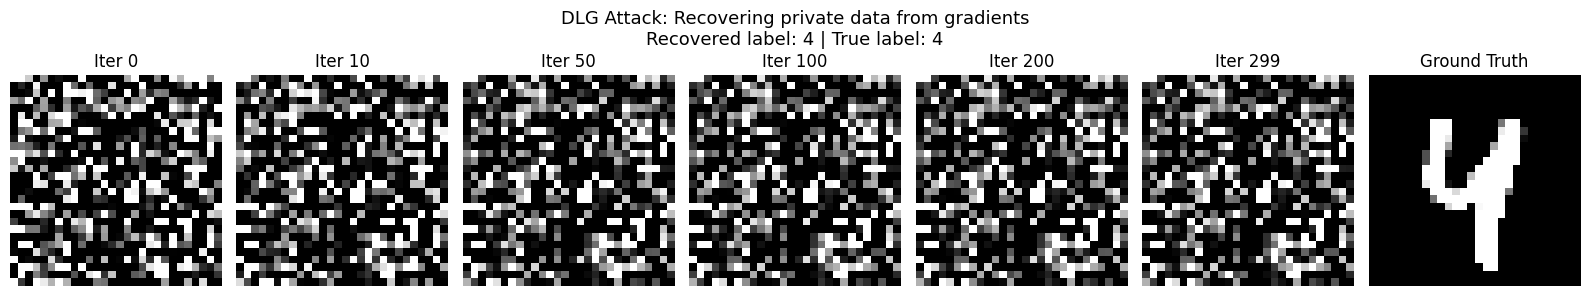

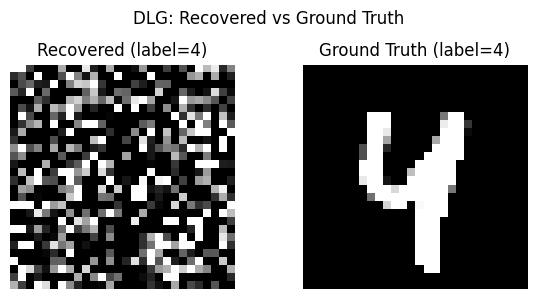

In [11]:

fig, axes = plt.subplots(1, len(history) + 1, figsize=(16, 3))

# Show the progression: noise -> recovered image
for idx, (iter_num, img) in enumerate(history):
    axes[idx].imshow(img[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[idx].set_title(f'Iter {iter_num}')
    axes[idx].axis('off')

# Show the ground truth (what the attacker never saw, but we know)
axes[-1].imshow(victim_image[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
axes[-1].set_title('Ground Truth')
axes[-1].axis('off')

plt.suptitle(f'DLG Attack: Recovering private data from gradients\n'
             f'Recovered label: {predicted_label} | True label: {victim_label.item()}',
             fontsize=13)
plt.tight_layout()
plt.show()

# Also show side-by-side comparison of final result
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(recovered_image[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Recovered (label={predicted_label})')
axes[0].axis('off')

axes[1].imshow(victim_image[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Ground Truth (label={victim_label.item()})')
axes[1].axis('off')

plt.suptitle('DLG: Recovered vs Ground Truth')
plt.tight_layout()
plt.show()
